# Laboratorio 4, Parte 2 — Modelos con datos geoespaciales

Cianobacteria en lagos Atitlán y Amatitlán. Este notebook parte de los rasters de la Parte I (`data/atitlan`, `data/amatitlan`, 9 bandas Sentinel-2 por fecha) y construye el conjunto de datos y los modelos de Machine Learning para clasificar zonas de alta/baja presencia de cianobacteria.

In [1]:
import glob
import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
from rasterio.warp import transform as warp_transform

DATA_DIR = Path("data")

ZONAS = {
    "atitlan": DATA_DIR / "atitlan",
    "amatitlan": DATA_DIR / "amatitlan",
}

# Mismo orden de bandas usado al descargar en la Parte I
BANDAS_TOTAL = ["B02", "B03", "B04", "B05", "B07", "B08", "B8A", "B11", "B12"]
IDX = {nombre: i + 1 for i, nombre in enumerate(BANDAS_TOTAL)}
print("Mapa de índices de bandas:", IDX)

Mapa de índices de bandas: {'B02': 1, 'B03': 2, 'B04': 3, 'B05': 4, 'B07': 5, 'B08': 6, 'B8A': 7, 'B11': 8, 'B12': 9}


## Ejercicio 1.1 / 1.2 — De raster a tabla por observación

Cada fila del dataset debe representar una observación geográfica válida (un píxel) dentro de un lago, en una fecha dada. Por cada `.tif`, leemos las 9 bandas, calculamos NDVI, NDWI y el índice de cianobacteria (mismas fórmulas de la Parte I), y obtenemos las coordenadas de cada píxel con `rasterio.transform.xy`:

```
NDVI  = (B08 - B04) / (B08 + B04)
NDWI  = (B03 - B08) / (B03 + B08)
CYANO = (B05 - B04) / (B05 + B04)
```

Guardamos tanto las coordenadas nativas del raster (`x`, `y`, en el CRS del `.tif`) como `lon`/`lat` en WGS84, porque el Ejercicio 6 de más adelante pide reproyectar a UTM y es más seguro partir de las coordenadas nativas que reproyectar dos veces.

In [2]:
def extraer_fecha(nombre_archivo: str) -> str:
    match = re.search(r"(\d{4}-\d{2}-\d{2})", nombre_archivo)
    return match.group(1) if match else None


def raster_a_dataframe(ruta_tif: str, lago: str) -> pd.DataFrame:
    """Convierte un raster multibanda (una fecha, un lago) en una tabla de píxeles."""
    fecha = extraer_fecha(os.path.basename(ruta_tif))

    with rasterio.open(ruta_tif) as src:
        bandas = {nombre: src.read(IDX[nombre]).astype("float32") for nombre in BANDAS_TOTAL}
        transform = src.transform
        crs = src.crs
        shape = src.shape
        nodata = src.nodata

    filas, cols = np.indices(shape)
    xs, ys = rasterio.transform.xy(transform, filas.ravel(), cols.ravel())
    xs, ys = np.asarray(xs), np.asarray(ys)

    if crs and not crs.is_geographic:
        lons, lats = warp_transform(crs, "EPSG:4326", xs, ys)
        lons, lats = np.asarray(lons), np.asarray(lats)
    else:
        lons, lats = xs, ys

    datos = {nombre.lower(): banda.ravel() for nombre, banda in bandas.items()}

    with np.errstate(divide="ignore", invalid="ignore"):
        b04, b08 = datos["b04"], datos["b08"]
        b03 = datos["b03"]
        b05 = datos["b05"]
        ndvi = (b08 - b04) / (b08 + b04)
        ndwi = (b03 - b08) / (b03 + b08)
        cyano = (b05 - b04) / (b05 + b04)

    df = pd.DataFrame({
        "lago": lago,
        "fecha": fecha,
        "x": xs,
        "y": ys,
        "lon": lons,
        "lat": lats,
        **datos,
        "ndvi": ndvi,
        "ndwi": ndwi,
        "cyano": cyano,
    })

    if nodata is not None:
        col_bandas = [nombre.lower() for nombre in BANDAS_TOTAL]
        es_nodata = (df[col_bandas] == nodata).any(axis=1)
        df.loc[es_nodata, col_bandas + ["ndvi", "ndwi", "cyano"]] = np.nan

    df["crs_nativo"] = str(crs)
    return df

## Ejercicio 1.3 — Limpieza: fuera del lago, NoData, nubes

El bounding box de descarga (Parte I) es rectangular y abarca tierra alrededor de cada lago, así que hay que recortar a los píxeles que sí son agua. Decisiones:

- **Máscara de agua**: `NDWI > 0` (umbral estándar de McFeeters, 1996, para delimitar cuerpos de agua con NDWI verde-NIR — misma fórmula que ya usamos en la Parte I). Todo lo que quede en o por debajo de 0 se descarta por ser tierra/vegetación/orilla.
- **NoData / NaN / inf**: se descartan filas con cualquier banda, NDVI, NDWI o cyano inválido (ya vienen como NaN desde `raster_a_dataframe` cuando el píxel es NoData).
- **Nubes**: la Parte I **no descargó la banda de máscara de nubes (SCL)**, así que no hay una forma directa de identificar nubes. Como aproximación, se descartan píxeles con reflectancia en B02 (azul) por encima del percentil 99 *dentro de cada imagen* — las nubes y neblina suelen verse como reflectancia anómalamente alta y pareja en todas las bandas visibles. Esto es una heurística, no una detección real de nubes; se documenta como limitación en el 1.6 y sería mejor resolverlo re-descargando con la banda SCL.

In [3]:
def limpiar_dataframe(df: pd.DataFrame, umbral_ndwi: float = 0.0, percentil_nube: float = 99.0) -> pd.DataFrame:
    col_bandas = [nombre.lower() for nombre in BANDAS_TOTAL]
    columnas_clave = col_bandas + ["ndvi", "ndwi", "cyano"]

    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(subset=columnas_clave)

    # Máscara de agua (McFeeters, 1996)
    df = df[df["ndwi"] > umbral_ndwi]

    # Heurística de nubes: reflectancia en B02 anómalamente alta, por fecha
    umbral_b02 = df.groupby("fecha")["b02"].transform(lambda s: np.percentile(s, percentil_nube))
    df = df[df["b02"] <= umbral_b02]

    return df.reset_index(drop=True)

In [4]:
def construir_dataset() -> pd.DataFrame:
    tablas = []
    for lago, carpeta in ZONAS.items():
        archivos = sorted(glob.glob(str(carpeta / "*.tif")))
        print(f"Procesando {lago}: {len(archivos)} archivos")
        for ruta_tif in archivos:
            try:
                df_crudo = raster_a_dataframe(ruta_tif, lago)
                df_limpio = limpiar_dataframe(df_crudo)
                tablas.append(df_limpio)
                print(f"  {os.path.basename(ruta_tif)}: {len(df_crudo)} px -> {len(df_limpio)} px válidos")
            except Exception as e:
                print(f"  [Error] {ruta_tif}: {e}")

    dataset = pd.concat(tablas, ignore_index=True)
    dataset["fecha"] = pd.to_datetime(dataset["fecha"])
    return dataset


dataset_ml = construir_dataset()
dataset_ml.to_parquet("dataset_ml_parte1.parquet", index=False)
print(f"\nDataset final: {dataset_ml.shape[0]} filas, {dataset_ml.shape[1]} columnas")
print("Guardado en dataset_ml_parte1.parquet")

Procesando atitlan: 11 archivos
  [Error] data\atitlan\atitlan_2025-01-18_bandas.tif: Read failed. See previous exception for details.
  atitlan_2025-04-13_bandas.tif: 4831009 px -> 1215255 px válidos
  atitlan_2025-05-13_bandas.tif: 4831009 px -> 1384766 px válidos
  atitlan_2025-07-17_bandas.tif: 4831009 px -> 1213246 px válidos
  atitlan_2025-11-21_bandas.tif: 4831009 px -> 1245188 px válidos
  atitlan_2025-12-29_bandas.tif: 4831009 px -> 1380508 px válidos
  atitlan_2026-02-12_bandas.tif: 4831009 px -> 1192083 px válidos
  atitlan_2026-03-24_bandas.tif: 4831009 px -> 1246184 px válidos
  atitlan_2026-04-13_bandas.tif: 4831009 px -> 1212250 px válidos
  atitlan_2026-04-28_bandas.tif: 4831009 px -> 1332653 px válidos
  [Error] data\atitlan\atitlan_2026-07-22_bandas.tif: Read failed. See previous exception for details.
Procesando amatitlan: 11 archivos
  amatitlan_2025-01-28_bandas.tif: 1247120 px -> 156354 px válidos
  amatitlan_2025-04-15_bandas.tif: 1247120 px -> 151406 px válidos


## Ejercicio 1.4 — Reporte del dataset

Total de observaciones, conteo por lago, conteo por fecha, variables disponibles con su tipo, y porcentaje de valores faltantes.

In [5]:
print(f"Total de observaciones: {len(dataset_ml)}\n")

print("Observaciones por lago:")
print(dataset_ml["lago"].value_counts(), "\n")

print("Observaciones por fecha:")
print(dataset_ml.groupby(["lago", "fecha"]).size(), "\n")

print("Tipos de variables:")
print(dataset_ml.dtypes, "\n")

faltantes = dataset_ml.isna().mean().sort_values(ascending=False) * 100
print("Porcentaje de valores faltantes por columna:")
print(faltantes[faltantes > 0] if (faltantes > 0).any() else "Sin valores faltantes (ya se descartaron en la limpieza).")

Total de observaciones: 13069970

Observaciones por lago:
lago
atitlan      11422133
amatitlan     1647837
Name: count, dtype: int64 

Observaciones por fecha:
lago       fecha     
amatitlan  2025-01-28     156354
           2025-04-15     151406
           2025-04-28     147247
           2025-11-24     152815
           2026-01-08     141626
           2026-02-02     138374
           2026-02-07     151826
           2026-03-29     155031
           2026-04-13     157075
           2026-04-28     135357
           2026-06-19     160726
atitlan    2025-04-13    1215255
           2025-05-13    1384766
           2025-07-17    1213246
           2025-11-21    1245188
           2025-12-29    1380508
           2026-02-12    1192083
           2026-03-24    1246184
           2026-04-13    1212250
           2026-04-28    1332653
dtype: int64 

Tipos de variables:
lago                  object
fecha         datetime64[ns]
x                    float64
y                    float64
lon    

## Ejercicio 1.5 — Análisis exploratorio

Histogramas de bandas e índices, boxplots por lago, y matriz de correlación entre las variables espectrales.

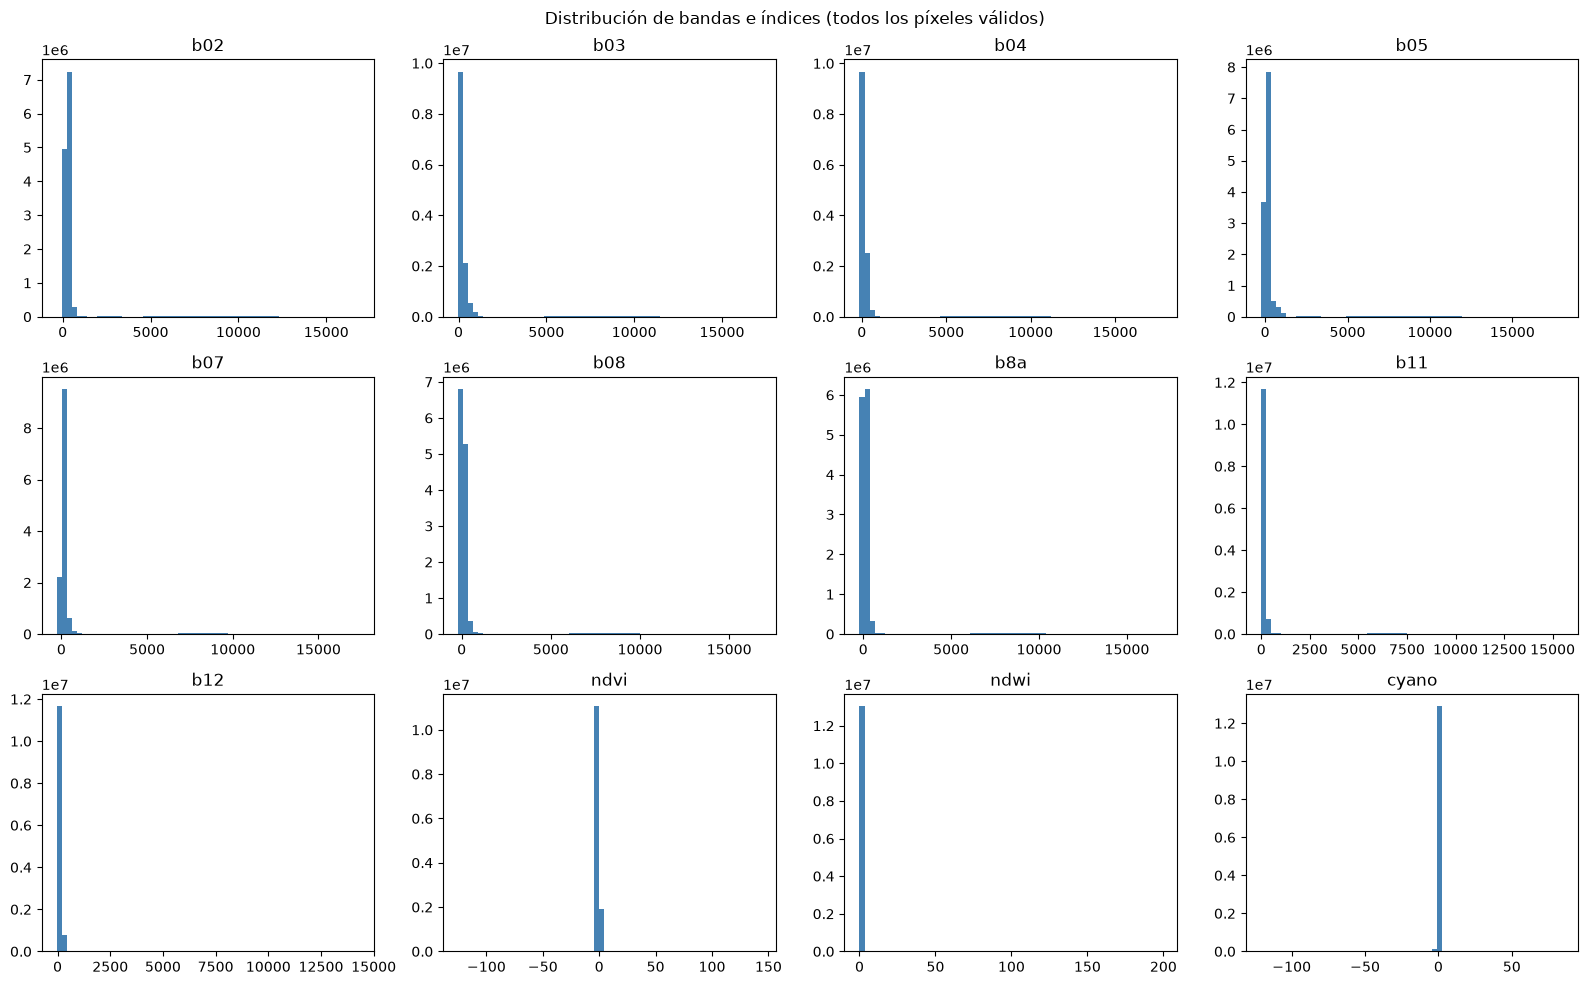

In [6]:
columnas_numericas = [nombre.lower() for nombre in BANDAS_TOTAL] + ["ndvi", "ndwi", "cyano"]

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for ax, col in zip(axes.ravel(), columnas_numericas):
    ax.hist(dataset_ml[col], bins=60, color="steelblue")
    ax.set_title(col)
for ax in axes.ravel()[len(columnas_numericas):]:
    ax.axis("off")
fig.suptitle("Distribución de bandas e índices (todos los píxeles válidos)")
fig.tight_layout()
plt.savefig(DATA_DIR / "hist_variables_parte2.png", dpi=150)
plt.show()

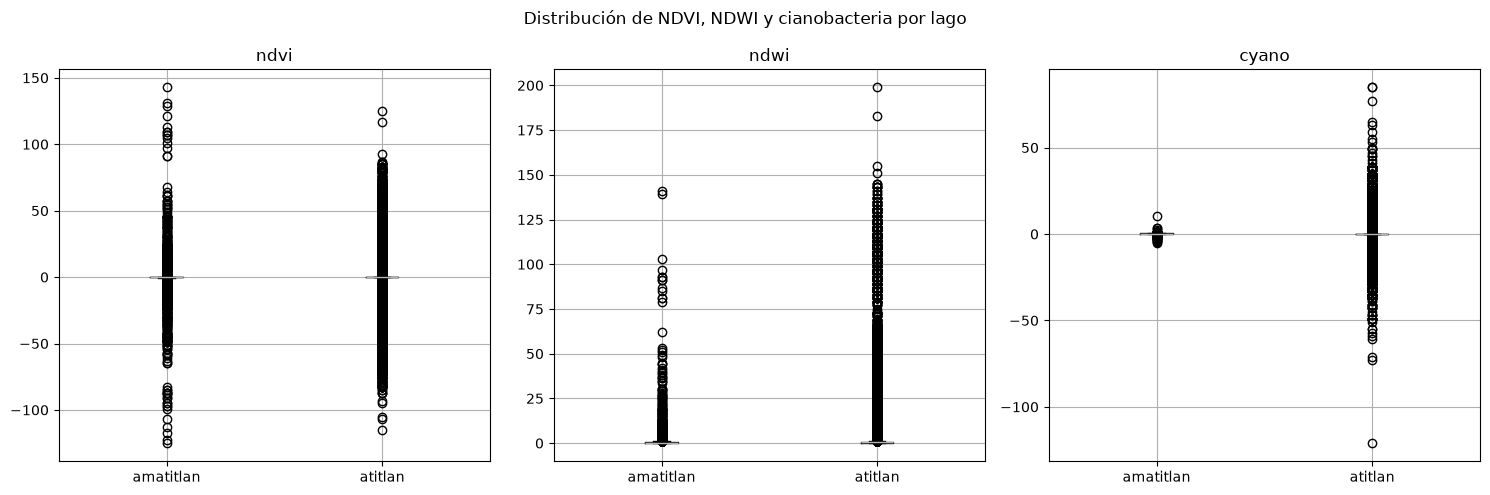

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, ["ndvi", "ndwi", "cyano"]):
    dataset_ml.boxplot(column=col, by="lago", ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
fig.suptitle("Distribución de NDVI, NDWI y cianobacteria por lago")
fig.tight_layout()
plt.savefig(DATA_DIR / "boxplot_variables_parte2.png", dpi=150)
plt.show()

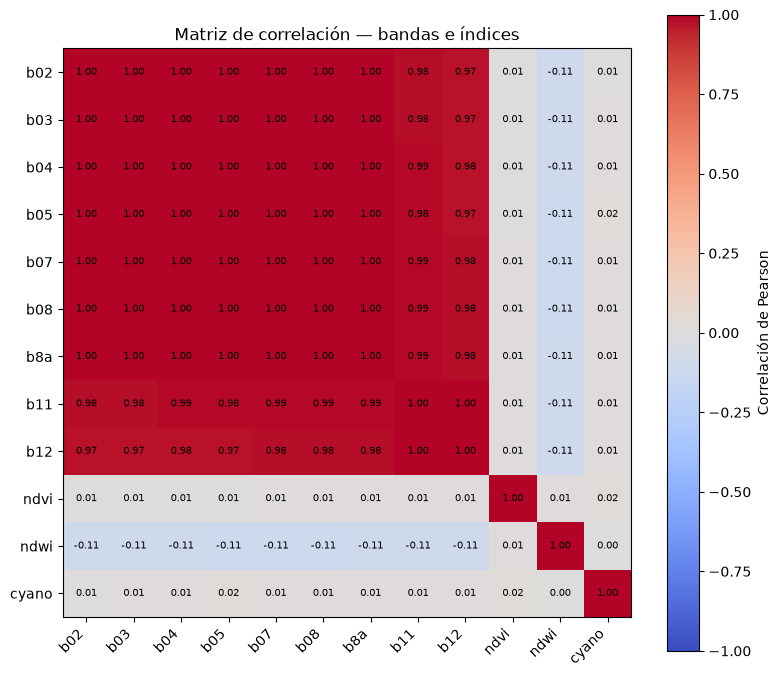

In [8]:
corr = dataset_ml[columnas_numericas].corr()

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(columnas_numericas)))
ax.set_xticklabels(columnas_numericas, rotation=45, ha="right")
ax.set_yticks(range(len(columnas_numericas)))
ax.set_yticklabels(columnas_numericas)
for i in range(len(columnas_numericas)):
    for j in range(len(columnas_numericas)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)
fig.colorbar(im, label="Correlación de Pearson")
ax.set_title("Matriz de correlación — bandas e índices")
fig.tight_layout()
plt.savefig(DATA_DIR / "correlacion_variables_parte2.png", dpi=150)
plt.show()

## Ejercicio 1.6: Decisiones de preparación y limpieza

Como grupo, tomamos las siguientes decisiones para preparar los datos:

- Trabajamos con cada píxel válido de las imágenes, tomando en cuenta la fecha y el lago al que pertenecía. Dejamos las bandas con el tamaño y la resolución originales.
- Guardamos las coordenadas `x`/`y` y también `lon`/`lat`. Decidimos guardar las dos porque algunos ejercicios necesitan las coordenadas en metros y otras veces es más práctico trabajar con longitud y latitud.
- Para separar el agua de la tierra, usamos la condición `NDWI > 0`. Elegimos esta opción porque es sencilla y ayuda a quitar los píxeles de tierra que aparecían dentro del área descargada.
- Quitamos las filas que tenían valores vacíos o inválidos, como `NaN` e `inf`. Estos valores podían aparecer cuando se dividía entre cero o cuando el raster tenía datos faltantes.
- Para las nubes usamos una aproximación, porque no teníamos la banda SCL. Eliminamos los píxeles con una reflectancia muy alta en B02, usando el percentil 99 como referencia. Sabemos que este método no es perfecto, porque podría dejar pasar algunas nubes o eliminar agua muy turbia.
- Conservamos B04, B05 y `cyano` porque todavía son parte de los datos preparados. Aun así, no los usaremos como predictores en el Ejercicio 3, ya que fueron utilizados para calcular la variable respuesta y eso podría causar *data leakage*.
- Finalmente, guardamos los datos limpios en `dataset_ml_parte1.parquet`. El archivo no se sube al repositorio por su tamaño, por lo que cada integrante debe generarlo ejecutando el notebook o conseguirlo por otro medio.